# Setup and Imports

In [11]:

%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
import sys
import os

# Add src folder to the path
sys.path.append(os.path.abspath('../src'))


from data_utils import load_bitstream, apply_error_correction
from sync import generate_zadoff_chu, append_sync_sequence

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# System Parameters

In [12]:
FS = 48000             # Sample rate (Hz)
F_CARRIER = 10000      # Center frequency (10 kHz is safely in your 2-18kHz window)

# Start conservative to test the channel, then increase for more points!
SYMBOL_RATE = 7000     # Symbols per second (Baud)

# Calculate how many audio samples represent one symbol
# 48000 Hz / 7000 Baud = 6.86 samples per symbol
SAMPLES_PER_SYMBOL = FS // SYMBOL_RATE 

print(f"Carrier Frequency: {F_CARRIER} Hz")
print(f"Symbol Rate: {SYMBOL_RATE} Baud")
print(f"Samples per Symbol: {SAMPLES_PER_SYMBOL}")
print(f"Main Lobe Bandwidth: ~{2 * SYMBOL_RATE} Hz (From {F_CARRIER - SYMBOL_RATE} Hz to {F_CARRIER + SYMBOL_RATE} Hz)")

Carrier Frequency: 10000 Hz
Symbol Rate: 7000 Baud
Samples per Symbol: 6
Main Lobe Bandwidth: ~14000 Hz (From 3000 Hz to 17000 Hz)


# Cell 3: Parameterized M-QAM Modulator

In [13]:
def map_bits_to_qam(bit_array, M=4):
    """Maps an array of bits to Square M-QAM complex symbols."""
    k = int(np.log2(M))
    if 2**k != M or k % 2 != 0:
        raise ValueError("M must be a perfect square (4, 16, 64, 256...)")

    pad_len = (k - len(bit_array) % k) % k
    if pad_len > 0:
        bit_array = np.append(bit_array, np.zeros(pad_len, dtype=int))

    symbols = []
    k_half = k // 2
    norm_factor = np.sqrt((2/3) * (M - 1))

    for i in range(0, len(bit_array), k):
        chunk = bit_array[i:i+k]
        I_bits = chunk[:k_half]
        Q_bits = chunk[k_half:]
        
        I_val = int("".join(map(str, I_bits)), 2)
        Q_val = int("".join(map(str, Q_bits)), 2)
        
        I_amp = 2 * I_val - (2**k_half - 1)
        Q_amp = 2 * Q_val - (2**k_half - 1)
        
        symbols.append(complex(I_amp, Q_amp) / norm_factor)
        
    return np.array(symbols)

# --- TOY MODEL CONFIGURATION ---
M = 256  # Change to 4, 16, 64, or 256
bits_per_symbol = int(np.log2(M))

# Let's generate enough bits for 1000 symbols
total_bits = 50000 * bits_per_symbol
random_bits = np.random.randint(0, 2, total_bits)

qam_symbols = map_bits_to_qam(random_bits, M)
print(f"Generated {len(qam_symbols)} complex symbols for {M}-QAM.")

Generated 50000 complex symbols for 256-QAM.


# Cell 4: Baseband Pulse Shaping & Passband Modulation

In [14]:
# 1. SQUARE PULSE SHAPING
# Repeat each complex symbol SAMPLES_PER_SYMBOL times. 
# This literally creates a "square" step in the time domain for each symbol.
baseband_signal = np.repeat(qam_symbols, SAMPLES_PER_SYMBOL)

# 2. UPCONVERSION (Modulate onto the carrier frequency)
# Create a time vector for the signal
t = np.arange(len(baseband_signal)) / FS

# Multiply the baseband signal by the complex carrier: e^(j * 2*pi * fc * t)
# Taking the real part gives us our physical, playable audio wave: I*cos(wt) - Q*sin(wt)
passband_signal = np.real(baseband_signal * np.exp(1j * 2 * np.pi * F_CARRIER * t))

# 3. Quick Tukey window to prevent speaker popping at the very start and end
from scipy.signal.windows import tukey
passband_signal = passband_signal * tukey(len(passband_signal), alpha=0.01)

print("Data payload successfully modulated to passband audio.")

Data payload successfully modulated to passband audio.


# Cell 5: Zadoff Chu + Export (TOSHITH)

Saved transmission file to: ../data/tx_single_carrier_test.wav


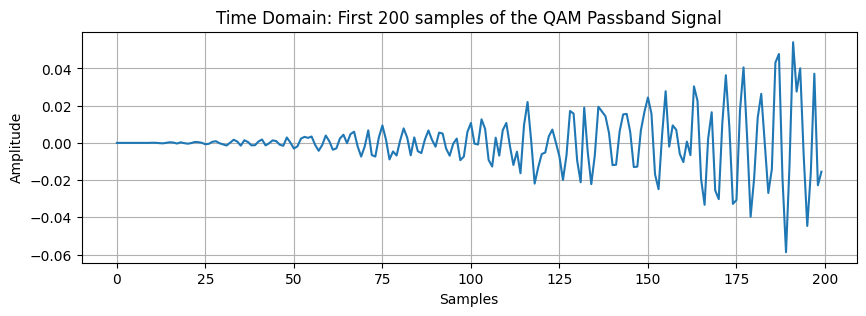

In [15]:
def generate_zadoff_chu_audio(fs):
    """
    Generate a Zadoff-Chu sequence as an audio signal for synchronization.
    upconvert it to the same carrier frequency as the data
    Return a 1D real-valued numpy array that can be played as audio.
    """
    print("Warning: Zadoff-Chu sync not yet implemented. Using empty array.")
    return np.array([]) 

# 1. Get the sync sequence from teammate's function
sync_audio = generate_zadoff_chu_audio(FS)

# 2. Create a small silence gap between the sync pulse and the data payload
# (Sir's notes mentioned the channel shouldn't change, but a small gap 
# prevents the sync correlation tail from interfering with the first data symbol)
silence_gap = np.zeros(int(FS * 0.05)) # 50 ms of silence

# 3. Assemble the final transmission frame
transmission_signal = np.concatenate([sync_audio, silence_gap, passband_signal])

# 4. Normalize audio to prevent clipping
if np.max(np.abs(transmission_signal)) > 0:
    transmission_signal = transmission_signal / np.max(np.abs(transmission_signal))

# Convert to 16-bit integer PCM for .wav export
transmission_signal_16bit = np.int16(transmission_signal * 32767)

# 5. Export
output_path = "../data/tx_single_carrier_test.wav"
wavfile.write(output_path, FS, transmission_signal_16bit)
print(f"Saved transmission file to: {output_path}")

# Plot a small snippet of the audio wave to verify the carrier is present
plt.figure(figsize=(10, 3))
# Plot just the first 200 samples of the passband data
plt.plot(passband_signal[:200])
plt.title("Time Domain: First 200 samples of the QAM Passband Signal")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()